In [7]:
import numpy as np
from scipy import stats
from scipy import special
from pandas import DataFrame

import statsmodels.api as sm
from patsy import dmatrices

import matplotlib.pyplot as plt

In [8]:
# Seed random generator
np.random.seed(12)

# Sample size
n = 100

# Create variables
wcc = np.round(np.random.normal(15, 5, n), 0)

crp = (wcc * 2) + np.round(np.random.normal(0, 10, n), 0)

lipase = wcc + crp + np.round(np.random.normal(2, 10, n), 0)

# Create dataframe
df = DataFrame({
    'WCC': wcc,
    'CRP': crp,
    'Lipase': lipase
})

# View first rows
df.head()

,WCC,CRP,Lipase
0,17.0,20.0,44.0
1,12.0,12.0,20.0
2,16.0,32.0,58.0
3,6.0,11.0,11.0
4,19.0,35.0,69.0


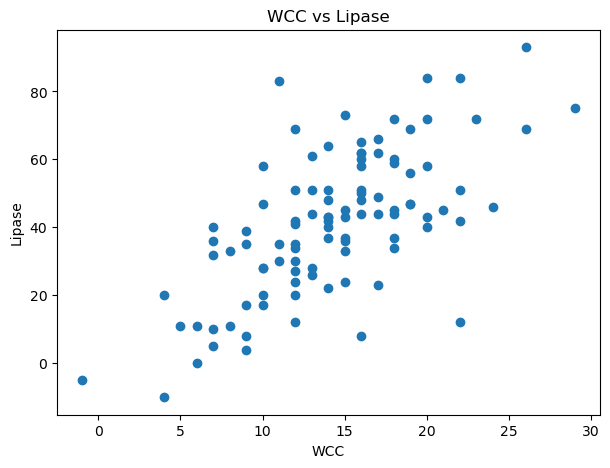

In [9]:
plt.figure(figsize=(7,5))

plt.scatter(df['WCC'], df['Lipase'])

plt.title('WCC vs Lipase')
plt.xlabel('WCC')
plt.ylabel('Lipase')

plt.show()

In [10]:
# Target vector and design matrix
y, X = dmatrices(
    'Lipase ~ WCC + CRP',
    data=df
)

# View X
X[:5]

array([[ 1., 17., 20.],
       [ 1., 12., 12.],
       [ 1., 16., 32.],
       [ 1.,  6., 11.],
       [ 1., 19., 35.]])

In [11]:
# Create model
model = sm.OLS(y, X).fit()

# Show summary
model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.759   
Dependent Variable: Lipase           AIC:                754.2907
Date:               2026-05-08 15:30 BIC:                762.1062
No. Observations:   100              Log-Likelihood:     -374.15 
Df Model:           2                F-statistic:        157.3   
Df Residuals:       97               Prob (F-statistic): 3.61e-31
R-squared:          0.764            Scale:              107.28  
-------------------------------------------------------------------
            Coef.    Std.Err.      t      P>|t|     [0.025   0.975]
-------------------------------------------------------------------
Intercept   2.3741     3.0129    0.7880   0.4326   -3.6056   8.3538
WCC         0.5426     0.2684    2.0213   0.0460    0.0098   1.0754
CRP         1.1827     0.1014   11.6636   0.0000    0.9814   1.3839
-----------------------------------------------------------------
Omnibus:              0.113        Durbin-Watson:           1.936
Prob(Omnibus):        0.945        Jarque-Bera (JB):        0.287
Skew:                 0.029        Prob(JB):                0.866
Kurtosis:             2.744        Condition No.:           96   
=================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
"""

# Task 2 — F Statistic Comment

The F statistic is large and the p value is very small.

There is enough evidence at the 5% significance level to show that at least one independent variable is linearly associated with Lipase.

# Task 3 — Coefficients and p Values

CRP has a very small p value, showing strong evidence that CRP is linearly associated with Lipase.

WCC also has a statistically significant p value.

The intercept is not statistically significant.

# Task 4 — R² Value

The R² value is approximately 0.76.

This means the model explains about 76% of the variability in Lipase values.

# Quiz Question 1 — Multiple Linear Regression Model

Create a multiple linear regression model using WCC and CRP as predictors of Lipase.

In [12]:
model = sm.OLS(y, X).fit()

model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.759   
Dependent Variable: Lipase           AIC:                754.2907
Date:               2026-05-08 15:30 BIC:                762.1062
No. Observations:   100              Log-Likelihood:     -374.15 
Df Model:           2                F-statistic:        157.3   
Df Residuals:       97               Prob (F-statistic): 3.61e-31
R-squared:          0.764            Scale:              107.28  
-------------------------------------------------------------------
            Coef.    Std.Err.      t      P>|t|     [0.025   0.975]
-------------------------------------------------------------------
Intercept   2.3741     3.0129    0.7880   0.4326   -3.6056   8.3538
WCC         0.5426     0.2684    2.0213   0.0460    0.0098   1.0754
CRP         1.1827     0.1014   11.6636   0.0000    0.9814   1.3839
-----------------------------------------------------------------
Omnibus:              0.113        Durbin-Watson:           1.936
Prob(Omnibus):        0.945        Jarque-Bera (JB):        0.287
Skew:                 0.029        Prob(JB):                0.866
Kurtosis:             2.744        Condition No.:           96   
=================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
"""

# Quiz Question 2 — F Statistic

Comment on the F statistic from the regression model.

The F statistic is very large and the p value is extremely small.

This indicates that at least one predictor variable is significantly associated with Lipase.

# Quiz Question 3 — Coefficients and p Values

Comment on the individual coefficients and their p values.

CRP has a statistically significant p value and is strongly associated with Lipase.

WCC is also statistically significant.

The intercept is not statistically significant.

# Quiz Question 4 — R² Value

Comment on the R² value from the regression model.

The R² value is about 0.76.

This means approximately 76% of the variation in Lipase is explained by the model.